# DPO4054 Waveform Viewer
Plot waveforms from a captured HDF5 file.

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

In [6]:
import re

def si_prefix(value):
    """Return (scale_factor, prefix) for a representative axis value."""
    abs_val = abs(value)
    for threshold, scale, prefix in [
        (1e-6, 1e9,  "n"),
        (1e-3, 1e6,  "µ"),
        (1.0,  1e3,  "m"),
        (1e3,  1.0,  ""),
        (1e6,  1e-3, "k"),
        (1e9,  1e-6, "M"),
    ]:
        if abs_val < threshold:
            return scale, prefix
    return 1.0, ""


def filter_captures(all_names, captures_filter):
    """
    Return capture names matching the filter list.
    Each entry in captures_filter is matched as an exact name OR as a
    base-label prefix (i.e. prefix + '_' + 3-digit index).
    """
    if captures_filter is None:
        return all_names
    result = []
    for name in all_names:
        for f in captures_filter:
            if name == f or re.match(rf"^{re.escape(f)}_\d{{3,}}$", name):
                result.append(name)
                break
    return result


_SERIES_RE = re.compile(r"^(.+)_(\d{3,})$")

def group_series(capture_names):
    """
    Partition capture_names into groups.

    Returns a list of (group_key, [names]) tuples.  Names that form a
    numbered series (base_001, base_002, …) are collected under their
    shared base label.  Standalone captures are their own single-item group.
    """
    bases = {}
    for name in capture_names:
        m = _SERIES_RE.match(name)
        key = m.group(1) if m else name
        bases.setdefault(key, []).append(name)

    result = []
    for key, names in bases.items():
        if len(names) == 1 and not _SERIES_RE.match(names[0]):
            # truly standalone — keep original name as key
            result.append((names[0], names))
        else:
            result.append((key, sorted(names)))
    return result


channel_colors = {"CH1": "C0", "CH2": "C1", "CH3": "C2", "CH4": "C3"}


def _make_axes(ch_names, title, notes):
    fig, axes = plt.subplots(
        len(ch_names), 1,
        figsize=(12, 3 * len(ch_names)),
        sharex=False,
        squeeze=False,
    )
    fig.suptitle(title, fontsize=12, fontweight="bold")
    if notes:
        fig.text(0.5, 0.97, notes, ha="center", va="top",
                 fontsize=9, style="italic", color="gray")
    return fig, axes[:, 0]


def plot_capture(capture_group, capture_name, channels=None):
    """Plot a single capture — one subplot per channel."""
    ch_names = sorted(
        k for k in capture_group.keys()
        if channels is None or k in channels
    )
    if not ch_names:
        print(f"  No matching channels in {capture_name}")
        return

    timestamp = capture_group.attrs.get("timestamp", "")
    notes     = capture_group.attrs.get("notes", "")
    title     = capture_name + (f"  [{timestamp}]" if timestamp else "")

    fig, axes = _make_axes(ch_names, title, notes)

    for ax, ch_name in zip(axes, ch_names):
        ch = capture_group[ch_name]
        t  = ch["time_s"][:]
        v  = ch["volts"][:]

        t_scale, t_prefix = si_prefix(t[-1] - t[0])
        ax.plot(t * t_scale, v, lw=0.8, color=channel_colors.get(ch_name, "C4"))
        ax.set_ylabel(f"{ch_name} (V)")
        ax.set_xlabel(f"Time ({t_prefix}s)")
        ax.grid(True, alpha=0.3)
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())

        meta_items = dict(ch.attrs)
        if meta_items:
            ax.set_title(
                "  ".join(f"{k}: {val}" for k, val in meta_items.items()),
                fontsize=8, loc="right", color="gray",
            )

    fig.tight_layout()
    plt.show()


def plot_series(base_label, named_groups, channels=None):
    """
    Overlay multiple captures (a numbered series) on a single figure.

    named_groups : list of (capture_name, capture_group) pairs, in order.
    """
    # Determine channel list from the first capture that has data
    ch_names = None
    for _, grp in named_groups:
        ch_names = sorted(
            k for k in grp.keys()
            if channels is None or k in channels
        )
        if ch_names:
            break
    if not ch_names:
        print(f"  No matching channels in series '{base_label}'")
        return

    n = len(named_groups)
    title = f"{base_label}  [{n} captures]"
    # Collect notes from each capture and de-duplicate
    all_notes = list(dict.fromkeys(
        grp.attrs.get("notes", "") for _, grp in named_groups
        if grp.attrs.get("notes", "")
    ))
    notes = " | ".join(all_notes)

    fig, axes = _make_axes(ch_names, title, notes)

    # Use a perceptually-uniform colormap scaled to the number of captures
    cmap = plt.get_cmap("viridis")
    colors = [cmap(i / max(n - 1, 1)) for i in range(n)]

    for ax, ch_name in zip(axes, ch_names):
        t_scale = t_prefix = None
        for idx, (cap_name, grp) in enumerate(named_groups):
            if ch_name not in grp:
                continue
            ch = grp[ch_name]
            t  = ch["time_s"][:]
            v  = ch["volts"][:]
            if t_scale is None:
                t_scale, t_prefix = si_prefix(t[-1] - t[0])
            ax.plot(
                t * t_scale, v,
                lw=0.7, alpha=0.8,
                color=colors[idx],
                label=cap_name,
            )

        ax.set_ylabel(f"{ch_name} (V)")
        ax.set_xlabel(f"Time ({t_prefix}s)")
        ax.grid(True, alpha=0.3)
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        if n <= 10:
            ax.legend(fontsize=7, loc="upper right")
        else:
            # Too many lines for a legend — use a colorbar instead
            sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(1, n))
            sm.set_array([])
            fig.colorbar(sm, ax=ax, label="capture index")

    fig.tight_layout()
    plt.show()

In [8]:
# ── Configuration ────────────────────────────────────────────────────────────
# HDF5_FILE = "data/waveforms_20260318_103008.h5"   # path to your .h5 file
HDF5_FILE = '/home/pioneer/josh/oscilloscope-readout-4054/data/waveforms_20260318_103558.h5'

# Set to a list of labels/prefixes to plot specific captures, or None for all.
# Exact labels ("capture_102144") and base-label prefixes ("run3_signal") both
# work — the prefix form matches all numbered captures in a series
# (e.g. "run3_signal" matches "run3_signal_001", "run3_signal_002", …).
CAPTURES = None

# Set to a list like ["CH1", "CH3"] to plot specific channels,
# or leave as None to plot all channels present in each capture.
CHANNELS = None

# When True, captures that share a base label (e.g. run3_signal_001 …_005)
# are overlaid on a single figure so you can compare repeated triggers.
# When False, every capture is plotted individually.
GROUP_SERIES = True

File: /home/pioneer/josh/oscilloscope-readout-4054/data/waveforms_20260318_103558.h5
  created: 2026-03-18T10:36:14.299806
  last_updated: 2026-03-18T10:36:14.300552
Captures (1): ['capture_103613']



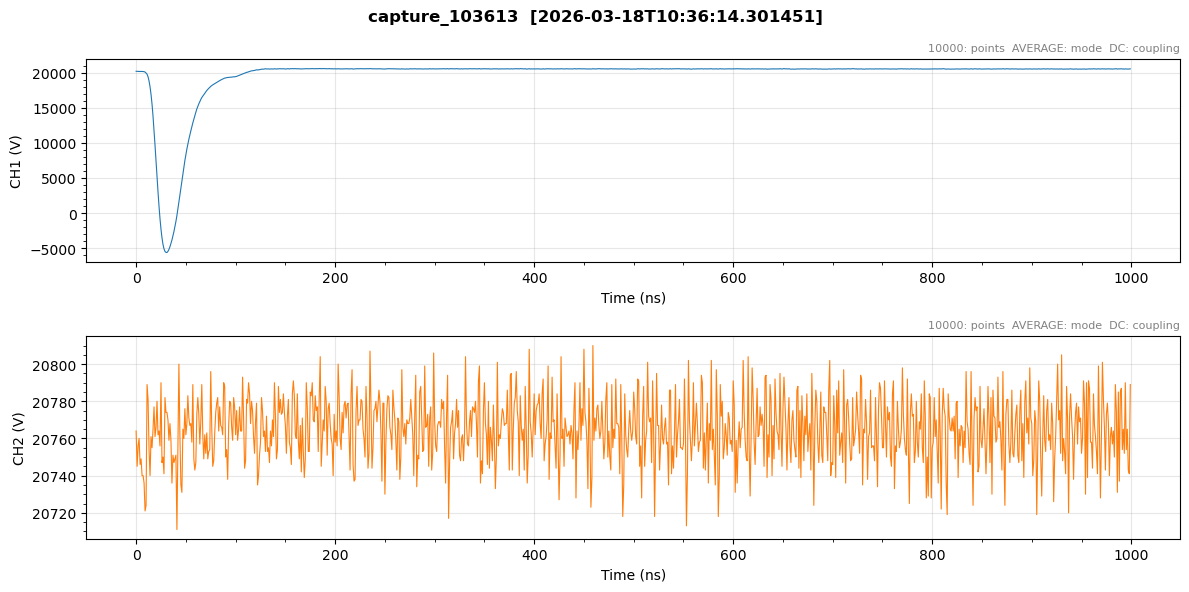

In [9]:
with h5py.File(HDF5_FILE, "r") as f:
    file_attrs = dict(f.attrs)
    all_names = sorted(f.keys())
    capture_names = filter_captures(all_names, CAPTURES)

    print(f"File: {HDF5_FILE}")
    if file_attrs:
        for k, v in file_attrs.items():
            print(f"  {k}: {v}")
    print(f"Captures ({len(capture_names)}): {capture_names}")
    print()

    if GROUP_SERIES:
        for base_label, names in group_series(capture_names):
            if len(names) == 1:
                plot_capture(f[names[0]], names[0], channels=CHANNELS)
            else:
                named_groups = [(n, f[n]) for n in names]
                plot_series(base_label, named_groups, channels=CHANNELS)
    else:
        for name in capture_names:
            plot_capture(f[name], name, channels=CHANNELS)